## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 2
---------------------------------------

GOALS:

1. Start using Python
2. Start looking at Data!

----------------------------------------------------------

This homework has **TWO** warm-up problems and **FOUR** problems.


## Hello World!

### Warm up Problem 1

Write python code that will print your name and run the cell.

In [4]:
# Your code here
print("Joseph Wong")

Joseph Wong


## Installing Modules

### Warm up Problem 2

Install the modules that you will need to run the rest of the code. You can copy and paste the commands from the class notes. This might take a minute or two to run... go get a cup of coffee :)

In [6]:
# Copy and paste the code here:
### This will take a while to run - just let it go.
!conda install -y numpy
!conda install -y pandas
!conda install -y matplotlib
!conda install -y plotly
!conda install -y itables
!conda install -y statsmodels
!conda install -y -c conda-forge python-kaleido

Retrieving notices: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\josee\anaconda3

  added / updated specs:
    - numpy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    openssl-3.3.2              |       h2466b09_0         8.0 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         8.0 MB

The following packages will be UPDATED:

  openssl                                  3.3.1-h2466b09_3 --> 3.3.2-h2466b09_0 



Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\jose

## Let's do some Data Science.

We will explore some data about how countries vote at the United Nations General Assembly. You should follow along with the notes and/or class video.

I am breaking this into parts and having you copy and paste the code so you can start to identify what the different parts of the code do.

-------------------------------
### Importing Packages:
-------------------------------

Every time we start a new project we will import the packages that will help us do the analysis. Copy and paste all of the imports in the cell below.

* numpy = mathematical and number packages for python
* pandas = pretty tables, dataframes, and data analysis packages
* matplotlib.pyplot = nice looking graphs
* plotly = nice looking graphs.
* itables = pretty looking tables that have a search bar

In [7]:
# Copy and paste the code here:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots

from itables import show

-------------------------------
### Get the Data:
-------------------------------

We will practice all sorts of ways to get data into our notebooks. When you use Pandas (pd) to read a csv:

    DF = pd.read_csv(file_location)

you are basically reading in a spreadsheet (Excel). The data for today is stored on my website.

It might take a minute for the data to load.

In [10]:
# Copy and paste the code here:
# Note this takes about a minute to run
file_location = 'https://joannabieri.com/introdatascience/data/unvotes.csv'
DF = pd.read_csv(file_location)
years = [int(d.split('-')[0]) for d in DF['date']]
DF['year'] = yearsx


-------------------------------
### Initial Data Exploration:
-------------------------------
-------------------------------
### Show the Data:
-------------------------------

We want to look at what we have. The data is now represented by the variable DF.

In [16]:
# Copy and paste the code here:
show(DF)

### Problem 1

Do some initial exploration of this data and write about it in the markdown cell below.

* How many columns are there?
* What do the columns represent?
* What countries are there?
* Can you search for a country you are interested in?
* How many rows are there?
* What other observations do you have?



* There are 15 columns.
* The columns represent different categories of data (i.e. country, date).
* There are 200 countries that have voted in the United Nations General Assembly such as the United States, Canada, and Cuba.
* The search bar allows me to search for specific countries.
* There are 546 rows, each representing a time that a country voted.
* Using the arrows next to the column headers allows me to sort the data by certain categories.

-------------------------------
### Make Python Explore the Data!:
-------------------------------

Copy and paste the command that will show you a list of the counties:

In [23]:
# Copy and paste the code here:
# Python can list all the different countries:
country_list = list(DF['country'].unique())

# Show the data in a nice way
show(pd.DataFrame(country_list,columns=['country']))

country
Loading ITables v2.1.4 from the internet... (need help?)


Copy and paste the command that will count up the number of countries:

In [27]:
# Copy and paste the code here:
# Python can count up the number of countries.
# Find the length of the list
print(len(country_list))

# Optional - Make a nice print statement
print(f'There are {len(country_list)} in our data set!')

200
There are 200 in our data set!


### Problem 2

Try writing some code for your self. Above we found a countries list by focusing on the column named 'country'. See if you can redo that same code but change it to focus on the column named 'issue'.

What do I expect here:

* First copy and past the code from above
* Then change that code slightly
* Run the cell to see if it worked

In [47]:
# Write your code here
issues_list = list(DF["issue"].unique())
issues_list

['Human rights',
 'Economic development',
 'Colonialism',
 'Palestinian conflict',
 'Arms control and disarmament',
 'Nuclear weapons and nuclear material']

-------------------------------
### Data Visualization:
-------------------------------

Now we will select three countries that we are interested in and see how their votes have changed over time. Below you should see code that selects: Turkey, United States, and United Kingdom.

**IMPORTANT** These have to be spelled and capitalized exactly like they are in the data. Python is unforgiving of typos!

You can just run the cell below - assuming you have done all the parts above!

In [51]:
countries = ['Turkey', 'United States', 'United Kingdom']
issues = list(DF['issue'].unique())
c_groups = DF.groupby(['country','issue'])
print(issues)

['Human rights', 'Economic development', 'Colonialism', 'Palestinian conflict', 'Arms control and disarmament', 'Nuclear weapons and nuclear material']


Now that we have our focus countries, we can make pretty pictures.

You can just run the cell below - assuming you have done all the parts above!

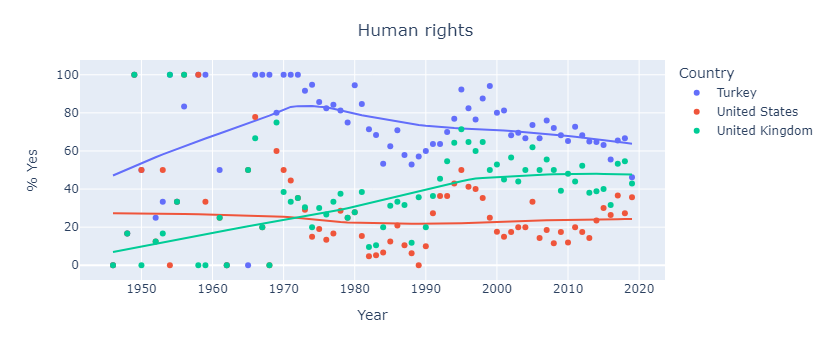

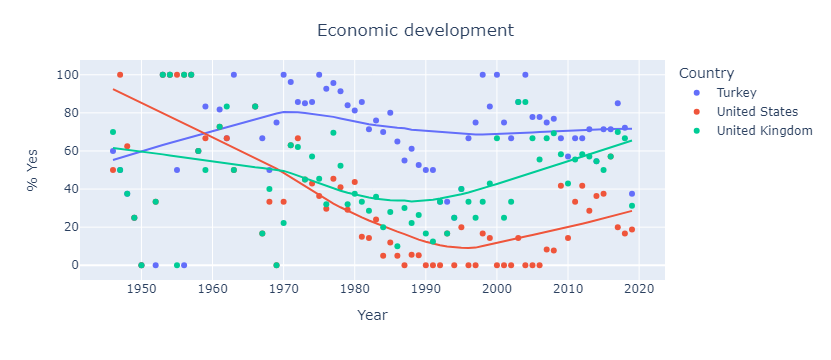

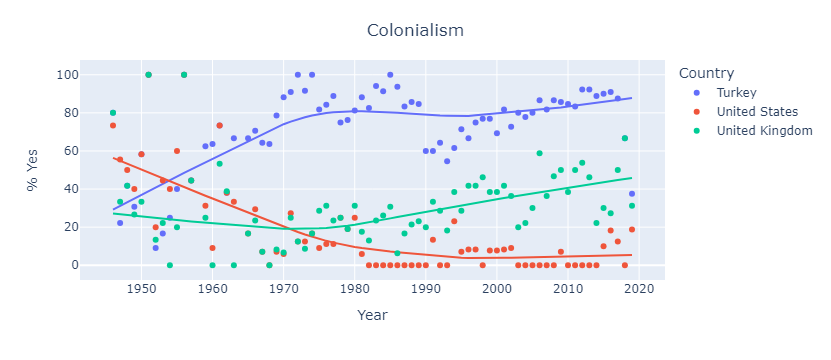

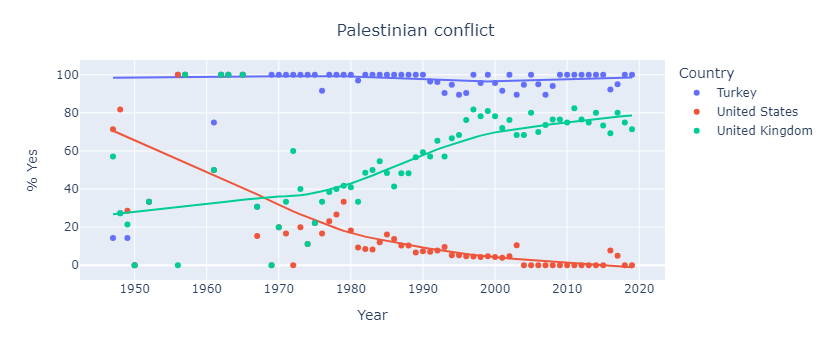

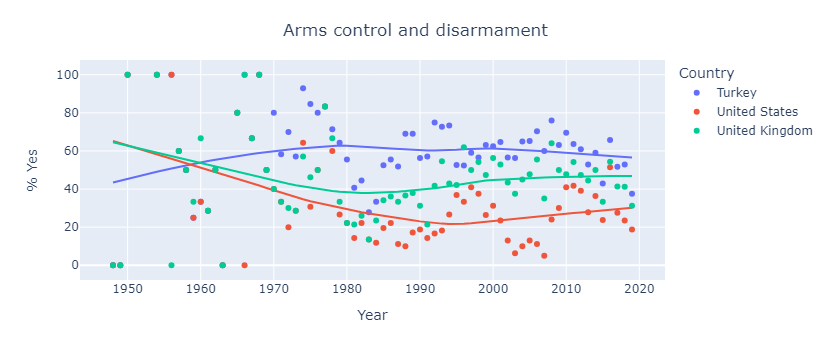

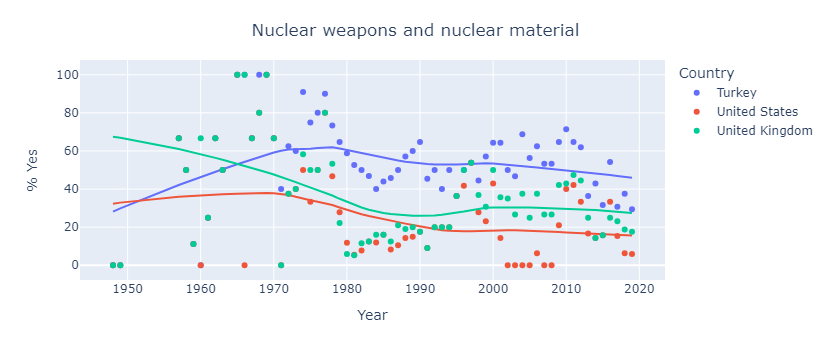

In [58]:
def make_plot(countries,issue):
    '''
    A Python function that takes in the list of countries and issues and makes
    a scatter plot of each issue with a trendline for each country.
    '''
    x_data = []
    y_data = []
    c_data = []
    for cntry in countries:
        my_group = c_groups.get_group((cntry,issue))
        for y in my_group['year'].unique():
            x_data.append(y)
            tot_yes = sum(my_group[my_group['year']==y]['vote']=='yes')
            percent_yes = tot_yes/len(my_group[my_group['year']==y])*100
            y_data.append(percent_yes)
            c_data.append(cntry)

    fig = px.scatter(x=x_data, y=y_data,color=c_data,trendline="lowess",labels={"color": "Country"})

    fig.update_layout(
        title={
            'text': issue + '<br>',
            'y':0.9,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'})
    fig.update_yaxes(title_text="% Yes")
    fig.update_xaxes(title_text="Year")
    fig.show()
    
for iss in issues:
    make_plot(countries,iss)

### Problem 3

Choose one of the graphs produced above (should match the lecture notes) and discuss what you see there:

1. Which issue are you focusing on.
2. What do the graph axis represent?
3. Say in words how the United States votes have changed over time.
4. How do the United States votes compare to the other countries?
5. See if you can come up with one or two questions that interest you about the data in the graph.

1. I am focusing on economic development.
2. The x-axis represents the year in which the vote took place. The y-axis represnts the percentage of "yes" votes from a country.
3. The United States' "yes" votes have been on the decline until around 1995, when they start to increase at a gradual rate.
4. The United Kingdom followed a similar trend of decreasing then increasing after around 1985. However, it's rate of change is more gradual than the United States. Unlike the other two countries, Turkey's "yes" votes were increasing until around 1970, when they began to decrease. Turkey's "yes" votes appear to be stable, starting around 2000. Another interesting thing I noticed is that Turkey's voting pattern doesn't follow the line of fit as closely as the United States' or United Kingdom's data.
5. What historical events influenced these changes (such as war, economic depression, shifts in leadership)?

### Problem 4

Now go back up to where we picked our three focus countries and choose some different ones. Rerun the analysis. If you want you could choose more than three countries. 

Discuss the graph for the same issue but with the new countries.

In [64]:
countries = ['Australia', 'Canada', 'France']
issues = list(DF['issue'].unique())
c_groups = DF.groupby(['country','issue'])
print(issues)

['Human rights', 'Economic development', 'Colonialism', 'Palestinian conflict', 'Arms control and disarmament', 'Nuclear weapons and nuclear material']


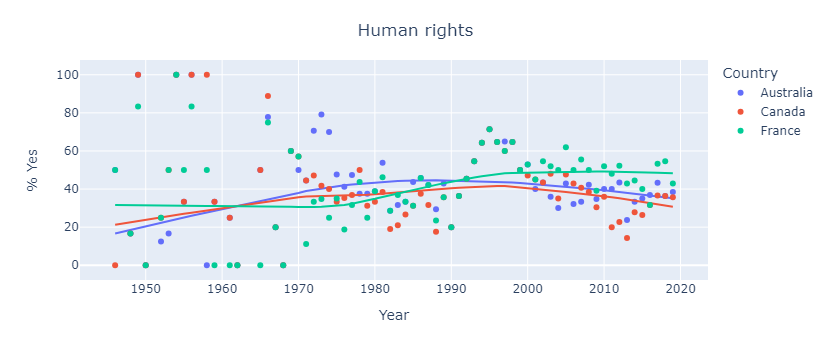

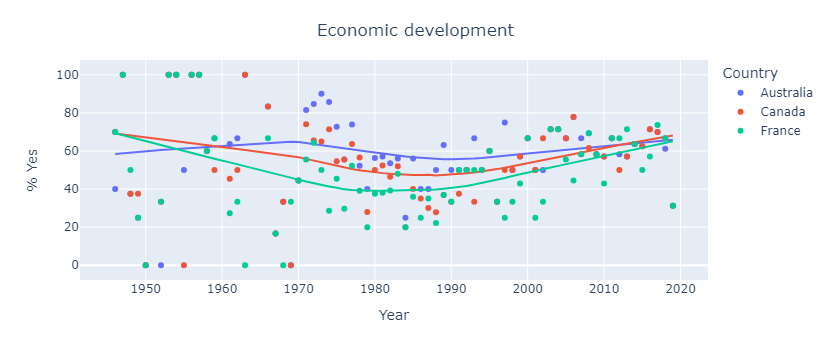

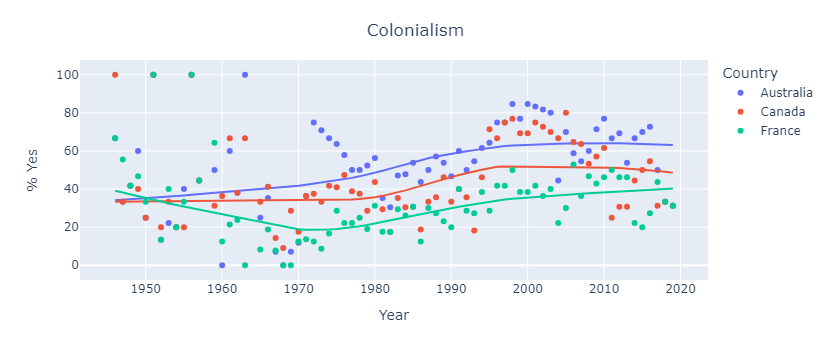

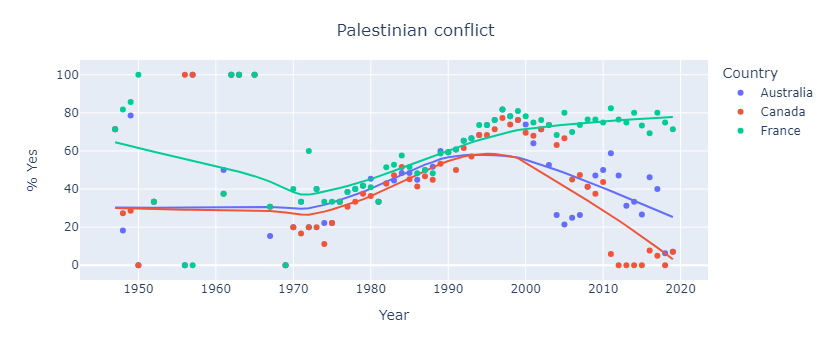

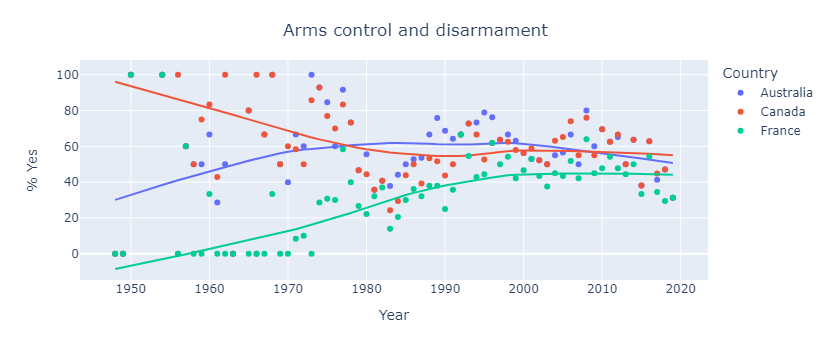

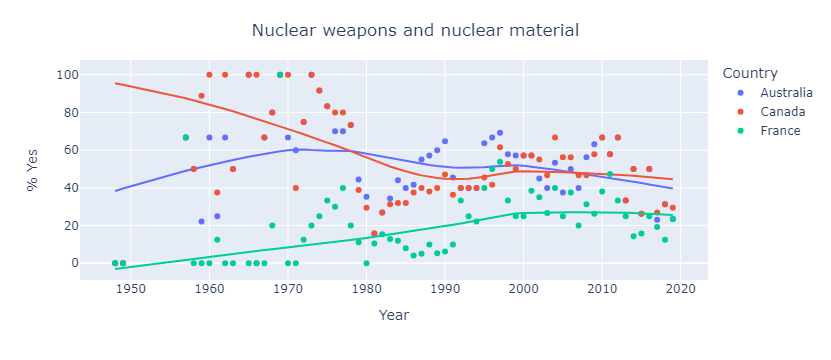

In [66]:
def make_plot(countries,issue):
    '''
    A Python function that takes in the list of countries and issues and makes
    a scatter plot of each issue with a trendline for each country.
    '''
    x_data = []
    y_data = []
    c_data = []
    for cntry in countries:
        my_group = c_groups.get_group((cntry,issue))
        for y in my_group['year'].unique():
            x_data.append(y)
            tot_yes = sum(my_group[my_group['year']==y]['vote']=='yes')
            percent_yes = tot_yes/len(my_group[my_group['year']==y])*100
            y_data.append(percent_yes)
            c_data.append(cntry)

    fig = px.scatter(x=x_data, y=y_data,color=c_data,trendline="lowess",labels={"color": "Country"})

    fig.update_layout(
        title={
            'text': issue + '<br>',
            'y':0.9,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'})
    fig.update_yaxes(title_text="% Yes")
    fig.update_xaxes(title_text="Year")
    fig.show()
    
for iss in issues:
    make_plot(countries,iss)

I am focusing on economic development.

Australia slightly increases until around 1970, where it starts to gradually decline. Around 1990, their "yes" votes begin to gradual increase. Canada decreases until around 1985, where it begins to increase at around the same rate as its original decline. France declines until around 1980, in which is remains almost stagnant. Around 1990, France's "yes" votes start to increase. All three countries follow a similar overall shape; they decline then begin to increase around the 1980-1990s. It is worth noting that all three countries stay close to the 40-70% range and do not have extreme increases or decreases.aph.

--------------------------------
### You are done with the homework... now what?
--------------------------------

1. Save your changes.
2. In the Git tab, **Stage** your changed files - use the (+) button next to the file.
3. **Commit** your changes by entering a summary and pushing commit.
4. **Push** your changes using the cloud button.
5. Check that your changes are on your GitHub repo (online)
6. **TAKE THE DAILY QUIZ ON CANVAS** the quiz will ask you to copy and past the HTTPS link to your repo for the day.
7. Come to class and get your questions answered.

At the end of the week  you will submit your final versions of the homework on Canvas for grading. For this you can just drag and drop the HW.ipynb files into canvas. 

**IMPORTANT** If this is confusing this first week, don't worry, I can help you and I will be really flexible about these first few deadlines.
